# GAME Category Deep Dive

Compare observed Free/Paid installs, primary genres and install skew in the same cleaned rated-app sample as the SQL analysis.

In [1]:
from pathlib import Path
PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data/googleplaystore.csv").exists())
(PROJECT_ROOT / "assets").mkdir(exist_ok=True)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

df = pd.read_csv(PROJECT_ROOT / "data/googleplaystore_cleaned.csv")
game_df = df[df["category"] == "GAME"].copy()

game_df["price"] = game_df["price"].astype(str).str.replace("$", "", regex=False)
game_df["price"] = pd.to_numeric(game_df["price"], errors="coerce").fillna(0)

game_df["Primary_Genre"] = game_df["genres"].str.split(";").str[0]
print(game_df.head())

                   app category  rating   reviews size    installs  type  \
1275            ROBLOX     GAME     4.5   4447388  67M   100000000  Free   
1276    Subway Surfers     GAME     4.5  27722264  76M  1000000000  Free   
1277  Candy Crush Saga     GAME     4.4  22426677  74M   500000000  Free   
1278         Solitaire     GAME     4.7    254258  23M    10000000  Free   
1279    Bubble Shooter     GAME     4.5    148897  46M    10000000  Free   

      price content_rating                        genres last_updated  \
1275    0.0   Everyone 10+  Adventure;Action & Adventure    31-Jul-18   
1276    0.0   Everyone 10+                        Arcade    12-Jul-18   
1277    0.0       Everyone                        Casual     5-Jul-18   
1278    0.0       Everyone                          Card     1-Aug-18   
1279    0.0       Everyone                        Casual    17-Jul-18   

       current_ver   android_ver Primary_Genre  
1275  2.347.225742    4.1 and up     Adventure  
1276  

In [2]:
# Compare installation performance of free vs paid games
free_paid_summary = (
    game_df.assign(is_free=(game_df["price"] == 0))
    .groupby("is_free")["installs"]
    .agg(["count", "mean", "median"])
)
free_paid_summary

,count,mean,median
is_free,,,
False,76,2.763061e+05,10000.0
True,836,1.657627e+07,1000000.0


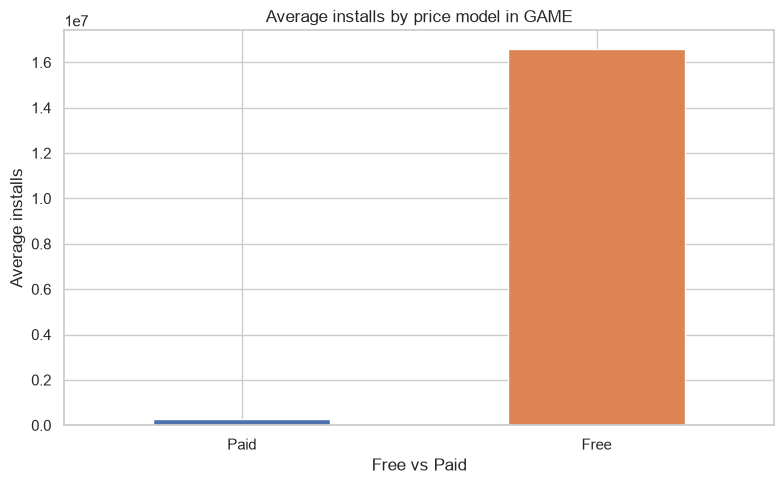

In [3]:
# Free vs paid comparison chart
ax = (
    game_df.assign(is_free=(game_df["price"] == 0))
    .groupby("is_free")["installs"]
    .mean()
    .plot(kind="bar", figsize=(8, 5), color=["#4c72b0", "#dd8452"])
)
ax.set_title("Average installs by price model in GAME")
ax.set_xlabel("Free vs Paid")
ax.set_ylabel("Average installs")
ax.set_xticklabels(["Paid", "Free"], rotation=0)
plt.tight_layout()
plt.show()

Free games have higher observed installs than Paid games. This association does not isolate the effect of price or prove a monetization strategy; age, marketing, app quality and selection can confound the comparison.

In [4]:
# Genre-level analysis in GAME
genre_summary = (
    game_df.groupby("Primary_Genre")["installs"]
    .agg(["count", "mean", "median"])
    .sort_values("median", ascending=False)
    .head(10)
)
genre_summary

,count,mean,median
Primary_Genre,,,
Sports,6,5.266667e+07,55000000.0
Casual,27,8.551852e+07,10000000.0
Puzzle,24,2.513333e+07,10000000.0
Strategy,17,2.690000e+07,10000000.0
Simulation,12,1.343333e+07,10000000.0
Role Playing,15,7.273333e+06,5000000.0
Word,22,7.689659e+06,3000000.0
Action,295,1.189165e+07,1000000.0
Racing,86,1.628193e+07,1000000.0


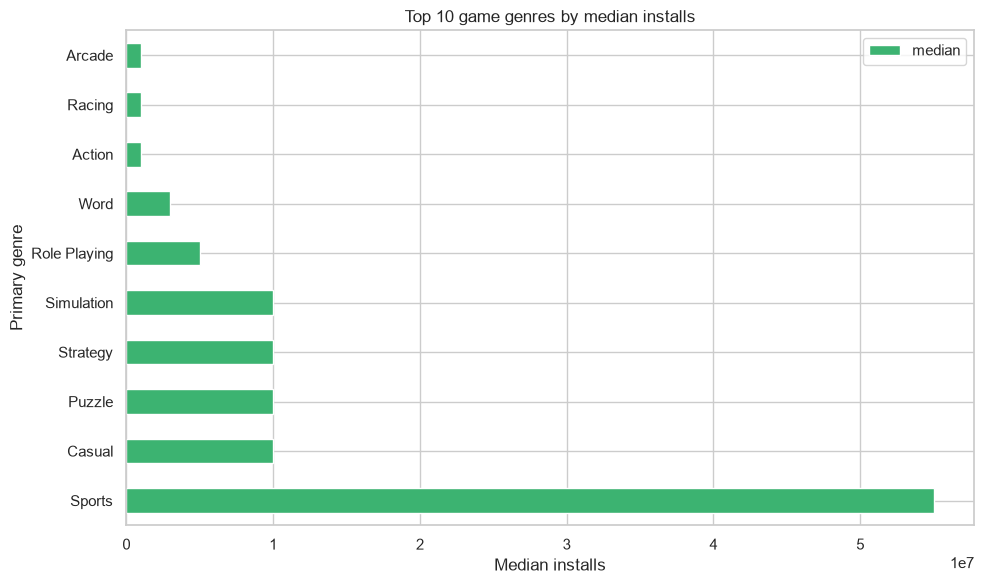

In [5]:
# Top 10 game genres by median installs
ax = genre_summary[["median"]].plot(kind="barh", figsize=(10, 6), color="mediumseagreen")
ax.set_title("Top 10 game genres by median installs")
ax.set_xlabel("Median installs")
ax.set_ylabel("Primary genre")
plt.tight_layout()
plt.show()

The median describes the middle app and is less sensitive to extreme values than the mean. High median installs do not establish lower acquisition costs or future opportunity.

Zero-install games excluded: 0


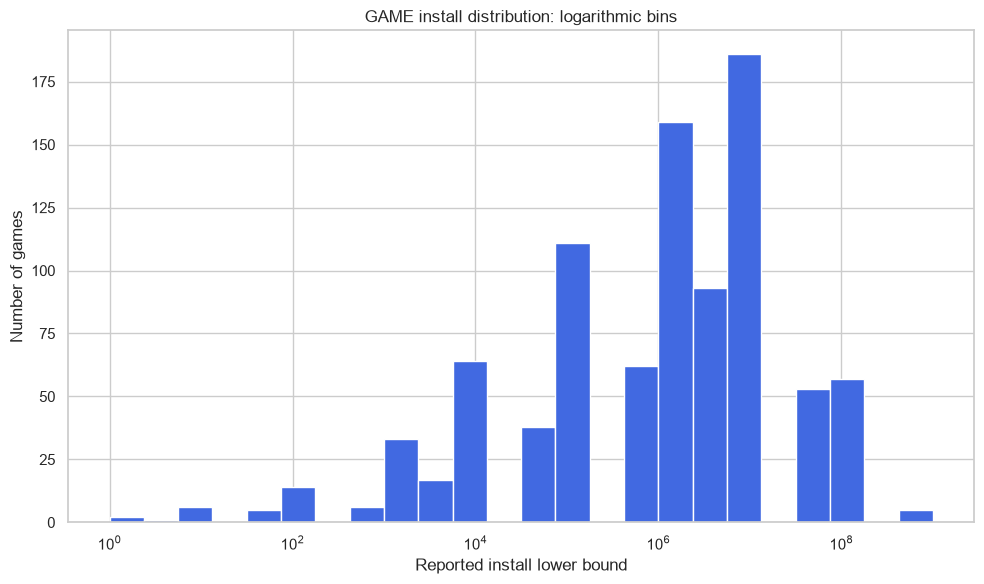

In [6]:
import numpy as np
positive = game_df.loc[game_df["installs"] > 0, "installs"]
print("Zero-install games excluded:", int((game_df["installs"] == 0).sum()))
bins = np.logspace(np.log10(positive.min()), np.log10(positive.max()), 25)
plt.figure(figsize=(10, 6))
plt.hist(positive, bins=bins, edgecolor="white", color="royalblue")
plt.xscale("log")
plt.title("GAME install distribution: logarithmic bins")
plt.xlabel("Reported install lower bound")
plt.ylabel("Number of games")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "assets/game_install_distribution_log_scale.png", dpi=200)
plt.show()

Logarithmically spaced bins reveal the distribution across orders of magnitude. Zero-install apps, if present, are excluded and reported explicitly.

## GAME conclusion

GAME leads total installs in the cleaned sample. Compare typical installs and concentration before forming product hypotheses. The snapshot cannot measure retention, revenue, acquisition costs, startup safety or passive-income potential.